supervisor 패턴의 agent를 구성

시장조사 agent
주식, 차트 agent
재무제표 agent

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

small_llm = ChatOpenAI(model="gpt-4o-mini")

In [3]:
%pip install --upgrade --quiet yfinance


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
from langchain_community.tools import YahooFinanceNewsTool
from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState
from langgraph.types import Command
from typing import Literal
from langchain_core.messages import HumanMessage

# 시장 조사 노드 생성
market_research_agent = create_react_agent(
    llm,
    tools=[YahooFinanceNewsTool()],
    state_modifier='You are a market research agent. Provide fact only not your opinions.'
)

def market_research_node(state: MessagesState) -> Command[Literal['supervisor']]:
    result = market_research_agent.invoke(state)
    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='market_research')]},
        goto='supervisor'
    )



USER_AGENT environment variable not set, consider setting it to identify your requests.


In [5]:

# stock data를 가져오는 노드 생성
import yfinance as yf
from langchain.tools import tool

@tool
def get_stock_data(ticker: str) -> dict:
    """Given a stock ticker, return the price data for the past 1 month"""
    stock_info = yf.download(ticker, period='1mo').to_dict()
    return stock_info

stock_research_tools = [get_stock_data]
stock_research_agent = create_react_agent(
    llm,
    tools=stock_research_tools,
    state_modifier='You are a stock research agent. Provide fact only not your opinions. must answer'
)

def stock_research_node(state: MessagesState) -> Command[Literal['supervisor']]:
    result = stock_research_agent.invoke(state)
    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='stock_research')]},
        goto='supervisor'
    )


In [6]:
# 재무제표를 가져오는 노드 생성

@tool
def company_research_tool(ticker: str) -> dict:
    """
    Given a ticker, return the financial statement for the past 1 year
    """
    company_info = yf.Ticker(ticker)
    financial_info = company_info.get_financials()
    sec_filings = company_info.get_sec_filings()
    return {
        'financial_info': financial_info,
        'sec_filings': sec_filings
    }

company_research_tools = [company_research_tool]
company_research_agent = create_react_agent(
    llm,
    tools=company_research_tools,
    state_modifier='You are a company research agent. Provide only fact financial statement and sec filings. not your opinions. must answer'
)

def company_research_node(state: MessagesState) -> Command[Literal['supervisor']]:
    result = company_research_agent.invoke(state)
    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='company_research')]},
        goto='supervisor'
    )


In [7]:
# 최종 분석 노드 생성
from langchain_core.prompts import PromptTemplate

analysis_prompt = PromptTemplate.from_template(
    """
    You are a final analysis agent.
    You will be given the following information:
    - Market research
    - Stock research
    - Company research
    - User request
    Your job is to analyze the information and provide a final invest recommendation.
    """
)

analysis_chain = analysis_prompt | llm

def analysis_node(state: MessagesState):
    result = analysis_chain.invoke({'messages': state['messages'][1:]})
    return {'messages': HumanMessage(content=result.content, name='analysis')}
    


In [8]:
# supervisor 노드 생성

from typing import Literal
from typing_extensions import TypedDict

from langgraph.graph import MessagesState, END
from langgraph.types import Command


members = ["market_research", "stock_research", "company_research"]
# Our team supervisor is an LLM node. It just picks the next agent to process
# and decides when the work is completed
options = members + ["FINISH"]

system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)


class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal[*options]


class State(MessagesState):
    next: str


def supervisor_node(state: State) -> Command[Literal[*members, "analysis"]]:
    messages = [
        {"role": "system", "content": system_prompt},
    ] + state["messages"]
    response = llm.with_structured_output(Router).invoke(messages)
    goto = response["next"]
    if goto == "FINISH":
        goto = "analysis"

    return Command(goto=goto, update={"next": goto})

In [9]:
# 최종 분석 노드 생성
from langchain_core.prompts import PromptTemplate

analysis_prompt = PromptTemplate.from_template(
    """
    You are a final analysis agent.
    You will be given the following information:
    - Market research
    - Stock research
    - Company research
    - User request
    Your job is to analyze the information and provide a final invest recommendation.
    """
)

analysis_chain = analysis_prompt | llm

def analysis_node(state: MessagesState):
    result = analysis_chain.invoke({'messages': state['messages'][1:]})
    return {'messages': [result]}
    


In [10]:
from langgraph.graph import StateGraph, START

graph_builder = StateGraph(MessagesState)

graph_builder.add_node("supervisor", supervisor_node)
graph_builder.add_node("market_research", market_research_node)
graph_builder.add_node("stock_research", stock_research_node)
graph_builder.add_node("company_research", company_research_node)
graph_builder.add_node("analysis", analysis_node)

In [11]:
graph_builder.add_edge(START, "supervisor")
graph_builder.add_edge("analysis", END)
graph = graph_builder.compile()

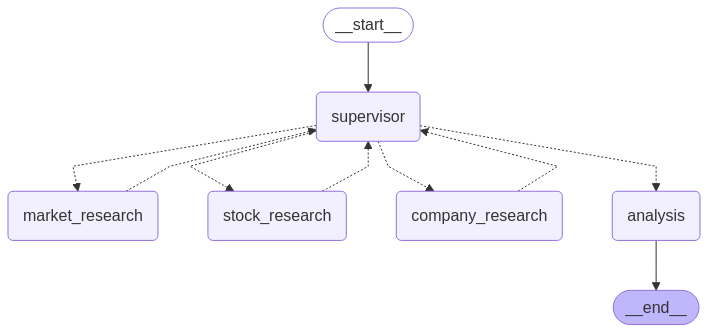

In [12]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
# 각 agent 노드에서 답변이 일정치 않아 튜닝이 필요하다.
for chunk in graph.stream(
    {"messages": [("user", "Would you invest in PLTR? please answer")]}, stream_mode="values"
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

Would you invest in PLTR? please answer
================================ Human Message =================================

Would you invest in PLTR? please answer
================================ Human Message =================================
Name: market_research

I wasn't able to find recent financial news for the company with the ticker PLTR. Make sure to check the latest available data and consult financial advisors for investment decisions.
================================ Human Message =================================
Name: market_research

I wasn't able to find recent financial news for the company with the ticker PLTR. Make sure to check the latest available data and consult financial advisors for investment decisions.
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


================================ Human Message =================================
Name: stock_research

I cannot provide investment advice. However, I can share the most recent stock price data for Palantir Technologies (PLTR) over the past month. 

Here is a summary of the closing prices over the past month:

- March 21, 2025: $90.96
- March 24, 2025: $96.75
- March 25, 2025: $96.50
- March 26, 2025: $92.28
- March 27, 2025: $90.09
- March 28, 2025: $85.85
- March 31, 2025: $84.40
- April 1, 2025: $84.68
- April 2, 2025: $87.45
- April 3, 2025: $83.60
- April 4, 2025: $74.01
- April 7, 2025: $77.84
- April 8, 2025: $77.32
- April 9, 2025: $92.01
- April 10, 2025: $88.59
- April 11, 2025: $88.55
- April 14, 2025: $92.62
- April 15, 2025: $98.40
- April 16, 2025: $92.71
- April 17, 2025: $93.78
- April 21, 2025: $94.00

Please consult with a financial advisor for personalized financial or investment advice.
================================ Human Message =================================
